# Project 3: Classification__

### __Objective__
In this lab, you will apply supervised learning (classification) models to predict one of the following
1. **Loan Approval Outcomes** : The dataset includes demographic, financial, and credit history features of loan applicants.
2. **Airline Passenger Satisfaction** : Customer satisfaction scores from 120,000+ airline passengers, including additional information about each passenger, their flight, and type of travel, as well as ther evaluation of different factors like cleanliness, comfort, service, and overall experience.
3. **Hotel Booking Cancellations** : booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces, among other things

### __Requirements__
Your task is to explore the data, clean and preprocess it appropriately, and build predictive models. Specifically, you must:
1. **Perform EDA**: Explore distributions, identify missing values, and check for class imbalance in the target variable.
2. **Preprocess the Data**: Handle categorical encodings, impute missing values, and scale your features. *Hint: Make sure to perform your train-test split BEFORE scaling to prevent data leakage!*
3. **Train Classification Models**: train **two** classification models (**Logistic Regression** and **KNN**).
5. **Evaluate & Compare**: Evaluate models using accuracy, precision, recall, F1-score, and confusion matrices. 

### __Deliverables__
You are expected to document your workflow using Markdown cells. Do not just write code; explain your **rationale**. Include insights from your EDA, justify your preprocessing decisions, and conclude with a comparative analysis discussing which of the three models performed best and why.

---

## __Data Dictionary__

___Copy you assigned dataset's dictionary from the guidleines___

---

## Setup and Data Loading
Import your libraries and load the dataset.

In [115]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your sklearn imports here...
from sklearn.model_selection import train_test_split, GridSearchCV

#Models
from sklearn.linear_model import LogisticRegression, LinearRegression, LassoCV, RidgeCV
from sklearn.neighbors import KNeighborsClassifier

#Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, confusion_matrix, precision_score
from sklearn import metrics
#Preprocessing
from sklearn.preprocessing import StandardScaler

#pipeline
from sklearn.pipeline import Pipeline


In [15]:
# Load the dataset
# df = pd.read_csv('...')
# df.head()
df = pd.read_csv('./data/aps.csv')
df.head(2)

,Unnamed: 0,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,0,1,male,48,First-time,business,Business,821 miles,2 minutes,5.0 minutes,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,1,2,FEMALE,35,returning,Business,Business,821 miles,26 minutes,39.0 minutes,...,5,4,5,5,3,5,2,5,5,Satisfied


## Part 1: Exploratory Data Analysis (EDA)
* What insights did you gain from your EDA? Are there missing values? Outliers? Is the target variable balanced or imbalanced? Use visualizations to support your findings.

In [16]:
# Your EDA code here 
# Note: you are not required to answer in this single cell, create more cells if needed
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136374 entries, 0 to 136373
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Unnamed: 0                              136374 non-null  int64
 1   ID                                      136374 non-null  int64
 2   Gender                                  136374 non-null  str  
 3   Age                                     136374 non-null  int64
 4   Customer Type                           136374 non-null  str  
 5   Type of Travel                          136374 non-null  str  
 6   Class                                   136374 non-null  str  
 7   Flight Distance                         136374 non-null  str  
 8   Departure Delay                         136374 non-null  str  
 9   Arrival Delay                           136374 non-null  str  
 10  Departure and Arrival Time Convenience  136374 non-null  int64
 11  Ease of Onl

In [17]:
df.describe()

,Unnamed: 0,ID,Age,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.00000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000
mean,68186.500000,64949.839676,39.415336,3.058919,2.756889,3.305733,3.251265,2.97762,3.382221,3.441052,3.351878,3.287049,3.204914,3.641779,2.728335,3.358639,3.632914
std,39367.927143,37493.148128,15.127551,1.526334,1.401928,1.265989,1.351787,1.27812,1.287022,1.319704,1.315613,1.313565,1.329990,1.176273,1.329397,1.333706,1.179430
min,0.000000,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,34093.250000,32495.250000,27.000000,2.000000,2.000000,3.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,68186.500000,64945.500000,40.000000,3.000000,3.000000,3.000000,3.000000,3.00000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,102279.750000,97404.750000,51.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,136373.000000,129880.000000,85.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [18]:
df[['Type of Travel','Customer Type','Gender','Class','Satisfaction']].value_counts()

Type of Travel  Customer Type  Gender  Class         Satisfaction           
Business        Returning      Female  Business      Satisfied                  5047
                               Male    Business      Satisfied                  4942
Personal        Returning      Male    Economy       Neutral or Dissatisfied    3798
                               Female  Economy       Neutral or Dissatisfied    3737
Business        Returning      Female   Business     Satisfied                  2174
                                                                                ... 
PERSONAL        returning      FEMALE   Business     Satisfied                     1
Personal         First-time    male    ECONOMY       Satisfied                     1
                               Female  Business      Neutral or Dissatisfied       1
                First-time     Male     Business     Neutral or Dissatisfied       1
business         First-time    Female  Economy Plus  Satisfied           

In [19]:
df['Gender'].value_counts()

Gender
Female    48470
Male      46992
FEMALE    20773
male      20139
Name: count, dtype: int64

In [20]:
df = df.drop(columns=['Unnamed: 0', 'ID'])

In [21]:
df

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,male,48,First-time,business,Business,821 miles,2 minutes,5.0 minutes,3,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,FEMALE,35,returning,Business,Business,821 miles,26 minutes,39.0 minutes,2,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853 miles,0 minutes,0.0 minutes,4,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,business,Business,1905 miles,0 minutes,0.0 minutes,2,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,returning,business,Business,3470 miles,0 minutes,1.0 minutes,3,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136369,Male,50,Returning,Business,Economy,1448 miles,7 minutes,32.0 minutes,1,5,...,2,5,2,5,5,4,5,5,2,Satisfied
136370,Female,44,Returning,Business,Business,3384 miles,0 minutes,0.0 minutes,5,4,...,3,4,3,5,5,3,5,3,3,Satisfied
136371,Female,43,Returning,Business,Business,373 miles,0 minutes,0.0 minutes,2,2,...,4,5,4,4,2,4,2,4,4,Satisfied
136372,Female,45,Returning,Business,Business,1583 miles,0 minutes,0.0 minutes,2,2,...,4,3,3,2,4,4,4,4,4,Neutral or Dissatisfied


In [22]:
df.isnull().sum()

Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                          0
Satisfaction                    

In [23]:
# to remove spaces and make everything lowercase

cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']

for col in cols:
    df[col] = df[col].astype(str).str.strip() 
    df[col] = df[col].str.lower()

In [24]:
#creating age category to group by satisfaction
"""

df2 = pd.read_csv('aps.csv')

#redoing the cleaning because new df

df2['Satisfaction'] = df2['Satisfaction'].astype(str).str.strip()

# 2. Define the new 10-year interval age bins and matching labels
bins = [0, 17, 31, 45, 59, 73, 100]
labels = ['Under 18', '18-31', '32-45', '46-59', '60-73', '74 and Over']

# 3. Create the new 10-year age group column
df2['Age Group Custom'] = pd.cut(df2['Age'], bins=bins, labels=labels)
df2.head(2)
"""

"\n\ndf2 = pd.read_csv('aps.csv')\n\n#redoing the cleaning because new df\n\ndf2['Satisfaction'] = df2['Satisfaction'].astype(str).str.strip()\n\n# 2. Define the new 10-year interval age bins and matching labels\nbins = [0, 17, 31, 45, 59, 73, 100]\nlabels = ['Under 18', '18-31', '32-45', '46-59', '60-73', '74 and Over']\n\n# 3. Create the new 10-year age group column\ndf2['Age Group Custom'] = pd.cut(df2['Age'], bins=bins, labels=labels)\ndf2.head(2)\n"

In [25]:
#Group by age group and satisfaction
"""
grouped = df2.groupby(['Age Group Custom', 'Satisfaction'], observed=False).size().unstack(fill_value=0)

#counts converted to %

pct_grouped = grouped.div(grouped.sum(axis=1), axis=0) * 100

# visualization done by AI

fig, ax = plt.subplots(figsize=(12, 6))
pct_grouped.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])

ax.set_title('Passenger Satisfaction Level by 10-Year Age Groups', fontsize=14, pad=15)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(pct_grouped.index, rotation=45)

ax.legend(title='Satisfaction', loc='upper left', bbox_to_anchor=(1.02, 1))

# for percentages inside box

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:  
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold',
                fontsize=9)

plt.tight_layout()

plt.savefig('10_year_age_groups_satisfaction.png')
plt.show()
plt.close()

"""

"\ngrouped = df2.groupby(['Age Group Custom', 'Satisfaction'], observed=False).size().unstack(fill_value=0)\n\n#counts converted to %\n\npct_grouped = grouped.div(grouped.sum(axis=1), axis=0) * 100\n\n# visualization done by AI\n\nfig, ax = plt.subplots(figsize=(12, 6))\npct_grouped.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])\n\nax.set_title('Passenger Satisfaction Level by 10-Year Age Groups', fontsize=14, pad=15)\nax.set_xlabel('Age Group', fontsize=12)\nax.set_ylabel('Percentage (%)', fontsize=12)\nax.set_xticklabels(pct_grouped.index, rotation=45)\n\nax.legend(title='Satisfaction', loc='upper left', bbox_to_anchor=(1.02, 1))\n\n# for percentages inside box\n\nfor p in ax.patches:\n    width, height = p.get_width(), p.get_height()\n    x, y = p.get_xy() \n    if height > 0:  \n        ax.text(x + width/2, \n                y + height/2, \n                f'{height:.1f}%', \n                ha='center', \n                va='center', \n                color='w

In [26]:
# the chart above helps us define our problem clearer, now I want to focus on adults

In [27]:
#problem statement of adults

df = df[df['Age'] >= 18]


In [28]:
df['Age'].min()

np.int64(18)

In [29]:
#removing miles, minutes and changing data types to help encoding

df['Flight Distance'] = df['Flight Distance'].str.replace(' miles', '')
df['Departure Delay'] = df['Departure Delay'].str.replace(' minutes', '')
df['Arrival Delay']   = df['Arrival Delay'].str.replace(' minutes', '')

df['Flight Distance'] = df['Flight Distance'].astype(int)
df['Departure Delay'] = df['Departure Delay'].astype(int)
df['Arrival Delay']  = df['Arrival Delay'].astype(float)

In [30]:
df.head(2)

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,male,48,first-time,business,business,821,2,5.0,3,3,...,3,5,2,5,5,5,3,5,5,neutral or dissatisfied
1,female,35,returning,business,business,821,26,39.0,2,2,...,5,4,5,5,3,5,2,5,5,satisfied


In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 126005 entries, 0 to 136373
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  126005 non-null  str    
 1   Age                                     126005 non-null  int64  
 2   Customer Type                           126005 non-null  str    
 3   Type of Travel                          126005 non-null  str    
 4   Class                                   126005 non-null  str    
 5   Flight Distance                         126005 non-null  int64  
 6   Departure Delay                         126005 non-null  int64  
 7   Arrival Delay                           125630 non-null  float64
 8   Departure and Arrival Time Convenience  126005 non-null  int64  
 9   Ease of Online Booking                  126005 non-null  int64  
 10  Check-in Service                        126005 non-null  int

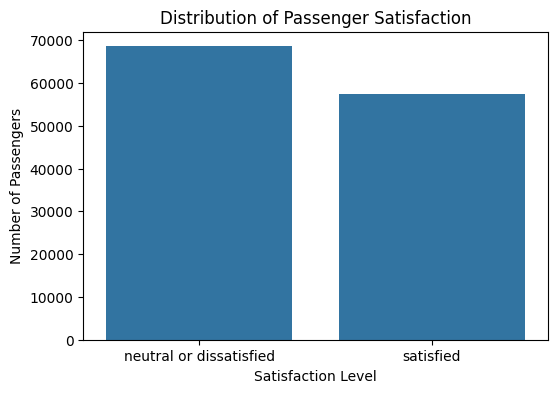

In [32]:
#EDA time

#used AI to plot

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Satisfaction')
plt.title('Distribution of Passenger Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Number of Passengers')
plt.show()

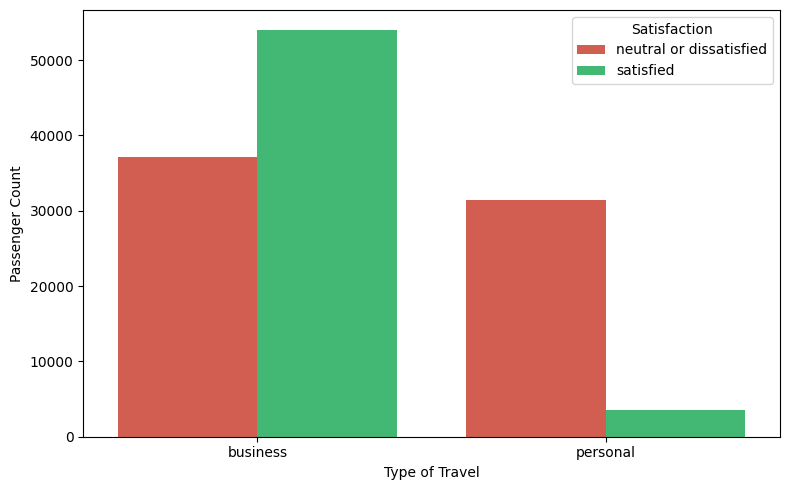

In [33]:
# type of travel vs satisfiaction using AI

custom_palette = {
    'neutral or dissatisfied': '#e74c3c',  # Modern red
    'satisfied': '#2ecc71'                 # Modern green
}

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Type of Travel', hue='Satisfaction', palette=custom_palette)

plt.xlabel('Type of Travel')
plt.ylabel('Passenger Count')
plt.legend(title='Satisfaction')
plt.tight_layout()
plt.savefig('travel_satisfaction.png', dpi=300)
plt.show()


# we can see that most personal passengers are neutral/dissatisfied

In [34]:

# The percentage distribution of Class for each Type of Travel
class_distribution = (
    pd.crosstab(df["Type of Travel"], df["Class"], normalize="index") * 100
)

print(class_distribution.round(2))

Class           business  economy  economy plus
Type of Travel                                 
business           67.16    27.50          5.34
personal            6.70    82.15         11.15


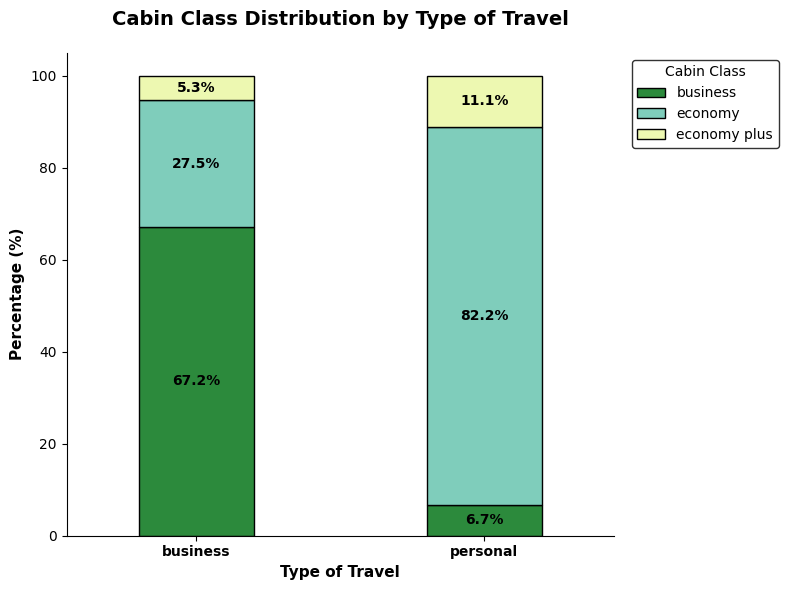

In [35]:

# Using AI to see each class distribution of type of travel

# 1. Calculate the percentage distribution of Class for each Type of Travel
class_distribution = (
    pd.crosstab(df["Type of Travel"], df["Class"], normalize="index") * 100
)

# 2. Set up the plot with a white background
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")

# 3. Create a stacked bar chart
# Using clean, distinct colors for Business, Economy, and Economy Plus
colors = ["#2c8a3c", "#7fcdbb", "#edf8b1"]
class_distribution.plot(
    kind="bar", stacked=True, ax=ax, color=colors, edgecolor="black", width=0.4
)

# 4. Add percentage labels inside each segment of the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 4:  # Only show label if the segment is large enough to fit text
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            color="black",
            weight="bold",
            fontsize=10,
        )

# 5. Format axes, titles, and labels with black text
ax.set_title(
    "Cabin Class Distribution by Type of Travel",
    fontsize=14,
    weight="bold",
    color="black",
    pad=20,
)
ax.set_xlabel("Type of Travel", fontsize=11, weight="bold", color="black")
ax.set_ylabel("Percentage (%)", fontsize=11, weight="bold", color="black")

# Clean up outer borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

# Adjust ticks and legend
plt.xticks(rotation=0, color="black", weight="bold")
plt.yticks(color="black")
ax.legend(
    title="Cabin Class",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor="white",
    edgecolor="black",
)

plt.tight_layout()

# Save the figure
plt.show()
plt.close()

In [36]:
df.to_csv('clean_aps.csv', index=False)


In [37]:
df = pd.read_csv('./data/aps.csv')


In [38]:
#satisfied = 1, else = 0

print(df['Satisfaction'].unique())

df['Satisfaction'] = df['Satisfaction'].astype(str).str.strip().str.lower()

df['Satisfaction_encoded'] = df['Satisfaction'].map({
    'satisfied': 1, 
    'neutral or dissatisfied': 0})

<StringArray>
['Neutral or Dissatisfied', 'Satisfied']
Length: 2, dtype: str


In [39]:
#correlation checking 

numeric_df = df.select_dtypes(include=['int64', 'float64'])
satisfaction_corr = numeric_df.corr()['Satisfaction_encoded'].sort_values(ascending=False)

# Print the correlation values
print("Correlation with Satisfaction:")
print(satisfaction_corr)

#Online boarding and inflight entertainment have the strongest positive correlations

Correlation with Satisfaction:
Satisfaction_encoded                      1.000000
Online Boarding                           0.502300
In-flight Entertainment                   0.397467
Seat Comfort                              0.348798
On-board Service                          0.321127
Leg Room Service                          0.311940
Cleanliness                               0.306417
In-flight Wifi Service                    0.283881
Baggage Handling                          0.248124
In-flight Service                         0.244553
Check-in Service                          0.237073
Food and Drink                            0.211764
Ease of Online Booking                    0.169346
Age                                       0.134349
ID                                        0.013628
Unnamed: 0                                0.010956
Gate Location                            -0.002812
Departure and Arrival Time Convenience   -0.054566
Name: Satisfaction_encoded, dtype: float64


In [91]:
#Using AI to chart the correlations

# 1. Ensure the 'satisfaction_encoded' column is created from 'Satisfaction'
if "satisfaction_encoded" not in df.columns and "Satisfaction" in df.columns:
    df["satisfaction_encoded"] = (df["Satisfaction"] == "satisfied").astype(int)

# 2. Select numeric columns and compute correlations
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["satisfaction_encoded"].drop(
    "satisfaction_encoded"
)

# 3. Extract the top 5 columns with the strongest absolute correlation
top_5_cols = correlations.abs().sort_values(ascending=False).head(5).index.tolist()
top_5_series = correlations.loc[top_5_cols].sort_values(ascending=False)

# 4. Plotting the Column Chart (Vertical Bars)
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")

# Generate a modern matching green palette gradient (dark to light)
green_palette = sns.color_palette("Greens_r", len(top_5_series))

# Create vertical bars
bars = ax.bar(
    top_5_series.index,
    top_5_series.values,
    color=green_palette,
    edgecolor="#1e4620",
    width=0.5,
)

# Add numerical labels on top of each column in standard black
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        va="bottom",
        ha="center",
        fontsize=10,
        weight="bold",
        color="black",
    )

# Formatting axes, titles, and labels with black text
ax.set_ylabel("Correlation Coefficient ($r$)", fontsize=11, weight="bold", color="black")
ax.set_title(
    "Top 5 Most Correlated Columns with Satisfaction",
    fontsize=14,
    weight="bold",
    color="black",
    pad=20,
)

# Clean up outer borders for a clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

# Format axis ticks with black labels
plt.xticks(rotation=25, ha="right", color="black", weight="bold")
plt.yticks(color="black")
plt.tight_layout()

# Save the figure
plt.savefig("correlation_column_chart.png", dpi=300)
plt.close()

In [43]:
## IMP : NEW df variable = new cleaned aps

df = pd.read_csv('./data/clean_aps.csv')

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126005 entries, 0 to 126004
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  126005 non-null  str    
 1   Age                                     126005 non-null  int64  
 2   Customer Type                           126005 non-null  str    
 3   Type of Travel                          126005 non-null  str    
 4   Class                                   126005 non-null  str    
 5   Flight Distance                         126005 non-null  int64  
 6   Departure Delay                         126005 non-null  int64  
 7   Arrival Delay                           125630 non-null  float64
 8   Departure and Arrival Time Convenience  126005 non-null  int64  
 9   Ease of Online Booking                  126005 non-null  int64  
 10  Check-in Service                        126005 non-null

## Part 2: Data Preprocessing
* Explain your strategy for handling categorical variables (e.g., One-Hot Encoding vs Label Encoding) and missing data.  
**Crucial:** Remember to split your data into training and testing sets BEFORE applying scaling to prevent data leakage.

In [45]:
# Your preprocessing, train_test_split, and scaling code here
# Note: you are not required to answer in this single cell, create more cells if needed

# ENCODING FIRST

df["satisfaction_encoded"] = (df["Satisfaction"] == "satisfied").astype(int)


df.to_csv("clean_aps.csv", index=False)

In [62]:
X = df.drop(columns=["Satisfaction", "satisfaction_encoded"])
y = df["satisfaction_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [68]:
## Arrival delay has NULLs so we replace by median

arrival_delay_median = X_train['Arrival Delay'].median()

# 4. Fill NaN with that median ONLY in the Arrival Delay column
X_train['Arrival Delay'] = X_train['Arrival Delay'].fillna(arrival_delay_median)
X_test['Arrival Delay'] = X_test['Arrival Delay'].fillna(arrival_delay_median)


## Part 3: Modeling
* Train your models.

In [ ]:
# Model 1.A Training & Prediction (KNN)

In [50]:
knn = KNeighborsClassifier()

In [95]:
from sklearn.preprocessing import OneHotEncoder

#kind of used AI 

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# fit_transform learns categories from train split; transform applies them to test split
X_train_encoded_vars = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded_vars = encoder.transform(X_test[categorical_cols])


# Extract Numeric Columns 
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

X_train_num = X_train[numeric_cols].values
X_test_num = X_test[numeric_cols].values


## combining and converting from STR

# Merge numeric matrices and encoded string matrices horizontally
X_train_combined = np.hstack((X_train_num, X_train_encoded_vars))
X_test_combined = np.hstack((X_test_num, X_test_encoded_vars))

# Explicitly cast to float to turn any leftover string formats into regular numbers
X_train_processed = X_train_combined.astype(float)
X_test_processed = X_test_combined.astype(float)


C:\Users\Hussain\AppData\Local\Temp\ipykernel_30048\3635091994.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [76]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [110]:
knn_model = KNeighborsClassifier()


knn_model.fit(X_train_processed, y_train)

## make predictions on the test
y_pred = knn_model.predict(X_test_processed)

In [111]:
## baseline precision success metric

precision = precision_score(y_test, y_pred)

print(f" BASELINE KNN Precision % = {precision * 100:.2f}%")



 BASELINE KNN Precision % = 73.85%


In [108]:
# Model 1.B Training & Prediction (Logistic Regression)

LR = LogisticRegression(max_iter=1000, random_state=42)

#Training here

LR.fit(X_train_processed, y_train)

y_pred_log = LR.predict(X_test_processed)



# the success metric
log_precision = precision_score(y_test, y_pred_log)

print(f" BASELINE LOGISTIC REGRESSION Precision %: {log_precision * 100:.2f}%")



 BASELINE LOGISTIC REGRESSION Precision %: 87.29%


C:\Users\Hussain\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [1]:
### HYPERPARAMETER OPTIMIZATION HERE ###

###########################################                                

In [122]:
# Using gridsearch to find k

knn_base = KNeighborsClassifier()


# We test different numbers of neighbors (k)

param_grid = {
    "n_neighbors": [5, 9, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],  # Different ways to calculate distance
}

# Set Up GridSearchCV 

# scoring='precision': Crucial! This tells the grid search to pick the winner based on Precision

grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    scoring="precision",
    cv=5,
    n_jobs=-2,
    verbose=1,
)

grid_search.fit(X_train_processed, y_train)
print("Grid Search complete!\n")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Grid Search complete!



In [119]:
## BEST KNN PARAMS

grid_search.best_params_

{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}

In [127]:
# KNN optimized test precision metric
grid_search.best_estimator_


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [128]:
print(f" Best CV KNN Precision: {grid_search.best_score_ * 100:.2f}%")

 Best CV KNN Precision: 83.23%


In [129]:
log_reg_base = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)


param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# --- 3. Set Up GridSearchCV ---
grid_search_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid_lr,
    scoring="precision",  
    cv=5,                 
    n_jobs=-1,            
    verbose=1,
)

grid_search_lr.fit(X_train_processed, y_train)
print("Grid Search complete!\n")



Fitting 5 folds for each of 6 candidates, totalling 30 fits
Grid Search complete!



C:\Users\Hussain\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [130]:
## BEST LR PARAMS

grid_search_lr.best_params_


{'C': 100.0}

In [131]:
print(f" Best Cross-Validation Precision: {grid_search_lr.best_score_ * 100:.2f}%")

## Not much different

 Best Cross-Validation Precision: 86.90%


In [134]:
best_log_model = grid_search_lr.best_estimator_
lr_test_predictions = best_log_model.predict(X_test_processed)
final_lr_precision = precision_score(y_test, lr_test_predictions)

print(f"Final Optimized Logistic Regression Precision on Test Set: {final_lr_precision * 100:.2f}%")

Final Optimized Logistic Regression Precision on Test Set: 87.06%


In [137]:
# Model 2 Training & Prediction
# Note: you are not required to answer in this single cell, create more cells if needed


from sklearn.compose import ColumnTransformer


## Shared Preprocessing Sub-Pipelines --- (AI

# This safely handles missing values and scaling for numeric columns
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
# This handles one-hot encoding for all categorical columns
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))]
)

# Combine them into a single preprocessor engine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


# Pipeline A: The Optimized KNN Model

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=15, metric="manhattan", weights="distance"
            ),
        ),
    ]
)

# Pipeline B: Optimized Logistic Regression Model

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(C=100.0, solver="lbfgs", max_iter=1000, random_state=42),
        ),
    ]
)


## Train Both Pipelines and Calculate Precision ---

knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)
knn_precision = precision_score(y_test, knn_preds)

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_precision = precision_score(y_test, lr_preds)

Training KNN Pipeline...
Training Logistic Regression Pipeline...


## Part 4: Evaluation
* Output the classification reports and confusion matrices for all models.

In [147]:
# Evaluation metrics
# Note: you are not required to answer in this single cell, create more cells if needed
## Final Project Comparison Table ---

print("       FINAL MODEL PRECISION COMPARISON      ")
print("=" * 45)
print(f" Optimized KNN  Precision : {knn_precision * 100:.2f}%")
print(f" Optimized Logistic Regression Precision : {lr_precision * 100:.2f}%")
print("=" * 45)


       FINAL MODEL PRECISION COMPARISON      
 Optimized KNN  Precision : 95.42%
 Optimized Logistic Regression Precision : 87.47%


In [144]:
# Using AI to check for overfitting

knn_train_preds = knn_pipeline.predict(X_train)
knn_train_precision = precision_score(y_train, knn_train_preds)

print("--- Overfitting Diagnostic Check ---")
print(f"KNN Training Precision: {knn_train_precision * 100:.2f}%")
print(f"KNN Testing Precision : {knn_precision * 100:.2f}%")

## Apparantly 100% KNN training is fine as long as the gap is under 5%

--- Overfitting Diagnostic Check ---
KNN Training Precision: 100.00%
KNN Testing Precision : 95.42%


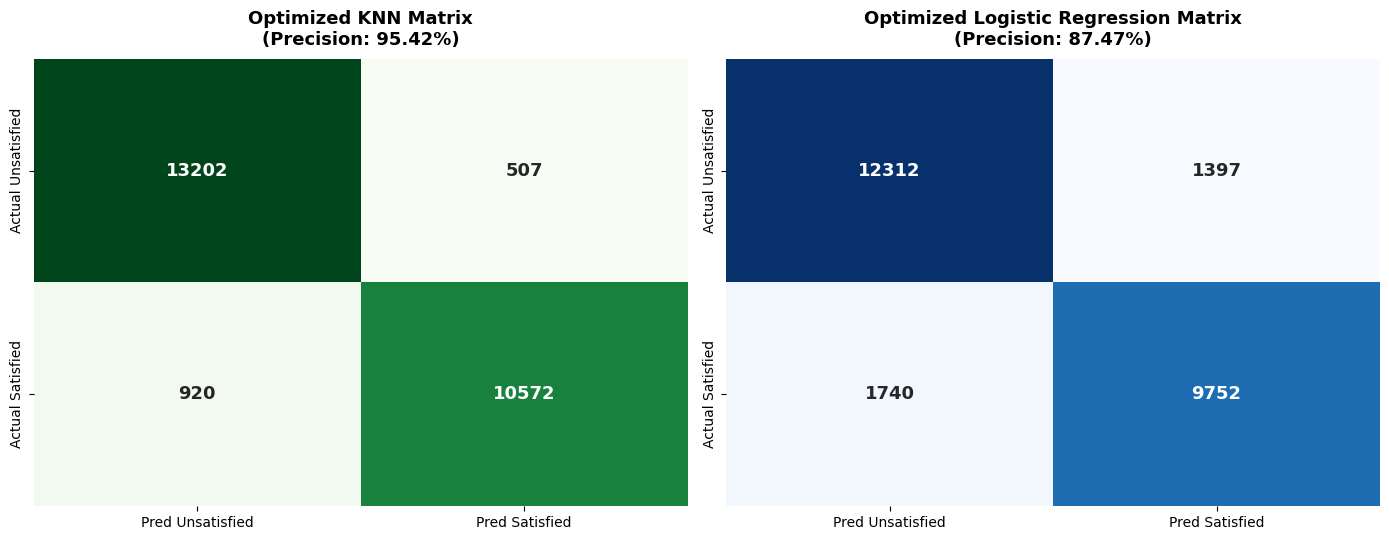

In [146]:
knn_cm = confusion_matrix(y_test, knn_preds)
lr_cm = confusion_matrix(y_test, lr_preds)

# Create a side-by-side plot to easily compare both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor="white")

# --- Plot 1: KNN Confusion Matrix ---
sns.heatmap(
    knn_cm, 
    annot=True, 
    fmt="d", 
    cmap="Greens", 
    cbar=False,
    xticklabels=["Pred Unsatisfied", "Pred Satisfied"],
    yticklabels=["Actual Unsatisfied", "Actual Satisfied"],
    annot_kws={"size": 13, "weight": "bold"},
    ax=axes[0]
)
axes[0].set_title("Optimized KNN Matrix\n(Precision: 95.42%)", fontsize=13, weight="bold", pad=10)

# --- Plot 2: Logistic Regression Confusion Matrix ---
sns.heatmap(
    lr_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=False,
    xticklabels=["Pred Unsatisfied", "Pred Satisfied"],
    yticklabels=["Actual Unsatisfied", "Actual Satisfied"],
    annot_kws={"size": 13, "weight": "bold"},
    ax=axes[1]
)
axes[1].set_title("Optimized Logistic Regression Matrix\n(Precision: 87.47%)", fontsize=13, weight="bold", pad=10)

# Adjust layout and save the visualization for your report
plt.tight_layout()
plt.savefig("model_evaluation_matrices.png", dpi=300)
plt.show()

## Part 5: Final Comparative Analysis
*(Double click this cell to edit)*

**Write your final conclusions here:**
The KNN model is the clear winner due to a higher precision rate (by 8%)

Furthermore, deploying KNN instead of Logistic Regression slashes financial waste from 12.5% down to just 4.5%
Which is good news for operating on a tight budget.
